<div style='background:linear-gradient(135deg,#1a1a2e,#16213e,#0f3460);padding:48px 40px;border-radius:18px;color:white;font-family:Georgia,serif;margin-bottom:24px'>
<p style='font-family:monospace;font-size:11px;letter-spacing:4px;color:#e8a838;margin-bottom:12px'>FÍSICA 10° · CINEMÁTICA · ANÁLISIS GRÁFICO DEL MOVIMIENTO</p>
<h1 style='font-size:2.4em;margin:0 0 16px;line-height:1.1'>Leer el movimiento<br><em style='color:#e8a838'>sin ecuaciones</em></h1>
<p style='font-size:1.1em;color:#c8c8d8;max-width:620px;line-height:1.7'>Un diálogo socrático sobre cómo los gráficos <strong style='color:white'>x–t</strong>, <strong style='color:white'>v–t</strong> y <strong style='color:white'>a–t</strong> revelan todo lo que necesitas saber sobre el movimiento de un cuerpo.</p>
<hr style='border:none;border-top:1px solid rgba(255,255,255,0.2);margin:24px 0'>
<p style='font-family:monospace;font-size:12px;color:#8888aa'>Lic. Hayzar Hernández Bustos · Corporación Universitaria Reformada · Barranquilla, Colombia</p>
</div>

## 🎯 Objetivos de aprendizaje

Al finalizar esta lectura interactiva serás capaz de:

1. **Interpretar** un gráfico x–t para determinar la velocidad como **pendiente** de la recta.
2. **Determinar** el desplazamiento en un gráfico v–t como el **área bajo la curva**.
3. **Calcular** la aceleración como la **pendiente** del gráfico v–t.
4. **Distinguir** entre rapidez media y velocidad media a partir de los gráficos.
5. **Relacionar** los tres tipos de gráficos (x–t, v–t, a–t) para describir el movimiento completo.
6. **Identificar** reposo, MRU y MRUA observando la forma de las curvas.

> 📌 **Cómo usar este notebook:** Lee los diálogos, analiza cada gráfico y responde las preguntas en las celdas habilitadas. Ejecuta cada celda de código para ver los gráficos.

---
## ⚙️ Configuración — ejecuta esta celda primero

In [6]:
!pip install scipy plotly -q
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline, CubicHermiteSpline
import warnings
warnings.filterwarnings('ignore')

try:
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    PLOTLY_OK = True
    print('✅ Plotly disponible — gráficos interactivos activados')
except ImportError:
    PLOTLY_OK = False
    print('⚠️  Plotly no disponible. Instala con: pip install plotly')

def estilo_tikz(ax, gc='#a8c8f0', bg='#eef4ff'):
    ax.set_facecolor(bg)
    ax.grid(True, color=gc, linewidth=0.8, linestyle='-')
    ax.set_axisbelow(True)
    for sp in ['top','right']: ax.spines[sp].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(labelsize=11)

AZUL='#1a4a8a'; ROJO='#c0392b'; VERDE='#1a7a6e'
NARANJA='#e67e22'; NEGRO='#1a1a1a'; MORADO='#7d3c98'
print('✅ Configuración lista. ¡Comenzamos!')

✅ Plotly disponible — gráficos interactivos activados
✅ Configuración lista. ¡Comenzamos!


---
# Sección 1 · Gráfico x–t por tramos — El automóvil en la carretera
### *(pAG-1)*

La siguiente gráfica representa la **posición (m)** en función del **tiempo (s)** de un automóvil que se mueve a lo largo de una carretera recta.

<div style='background:#f0f4ff;border-radius:14px;padding:28px;font-family:Georgia,serif;line-height:1.8;border:1px solid #c8d4f0'>
<p style='font-family:monospace;font-size:10px;letter-spacing:3px;color:#2c5f8a;margin-bottom:16px'>DIÁLOGO SOCRÁTICO — ESCENA 1</p>

<div style='display:flex;gap:12px;margin-bottom:18px;align-items:flex-start'>
<div style='background:#2c5f8a;color:white;border-radius:50%;width:38px;height:38px;display:flex;align-items:center;justify-content:center;font-weight:bold;flex-shrink:0'>P</div>
<div style='background:white;padding:14px 18px;border-radius:0 14px 14px 14px;border:1px solid #dde4f5;max-width:85%'>Daniel, mira el gráfico. Hay tres tramos. ¿Qué diferencia notas en cada uno?</div></div>

<div style='display:flex;gap:12px;margin-bottom:18px;align-items:flex-start;flex-direction:row-reverse'>
<div style='background:#1a7a6e;color:white;border-radius:50%;width:38px;height:38px;display:flex;align-items:center;justify-content:center;font-weight:bold;flex-shrink:0'>D</div>
<div style='background:white;padding:14px 18px;border-radius:14px 0 14px 14px;border:1px solid #dde4f5;max-width:85%'>El primero baja, el segundo sube, y el tercero es horizontal.</div></div>

<div style='display:flex;gap:12px;margin-bottom:18px;align-items:flex-start'>
<div style='background:#2c5f8a;color:white;border-radius:50%;width:38px;height:38px;display:flex;align-items:center;justify-content:center;font-weight:bold;flex-shrink:0'>P</div>
<div style='background:white;padding:14px 18px;border-radius:0 14px 14px 14px;border:1px solid #dde4f5;max-width:85%'>Bien. Ahora tradúcelo al movimiento del automóvil. ¿Qué hace en cada tramo?</div></div>

<div style='display:flex;gap:12px;margin-bottom:18px;align-items:flex-start;flex-direction:row-reverse'>
<div style='background:#1a7a6e;color:white;border-radius:50%;width:38px;height:38px;display:flex;align-items:center;justify-content:center;font-weight:bold;flex-shrink:0'>D</div>
<div style='background:white;padding:14px 18px;border-radius:14px 0 14px 14px;border:1px solid #dde4f5;max-width:85%'>En el primero, la posición disminuye: se aleja hacia el lado negativo. En el segundo regresa, y en el tercero está quieto: la posición no cambia.</div></div>

<div style='display:flex;gap:12px;margin-bottom:18px;align-items:flex-start'>
<div style='background:#2c5f8a;color:white;border-radius:50%;width:38px;height:38px;display:flex;align-items:center;justify-content:center;font-weight:bold;flex-shrink:0'>P</div>
<div style='background:white;padding:14px 18px;border-radius:0 14px 14px 14px;border:1px solid #dde4f5;max-width:85%'>¿Cuál tramo tiene mayor velocidad? ¿Cómo lo sabes <em>sin calcular nada</em>?</div></div>

<div style='display:flex;gap:12px;margin-bottom:0;align-items:flex-start;flex-direction:row-reverse'>
<div style='background:#1a7a6e;color:white;border-radius:50%;width:38px;height:38px;display:flex;align-items:center;justify-content:center;font-weight:bold;flex-shrink:0'>D</div>
<div style='background:white;padding:14px 18px;border-radius:14px 0 14px 14px;border:1px solid #dde4f5;max-width:85%'>El primero, porque la recta es más inclinada. En el mismo tiempo recorre más posición. La pendiente es mayor en valor absoluto.</div></div>
</div>

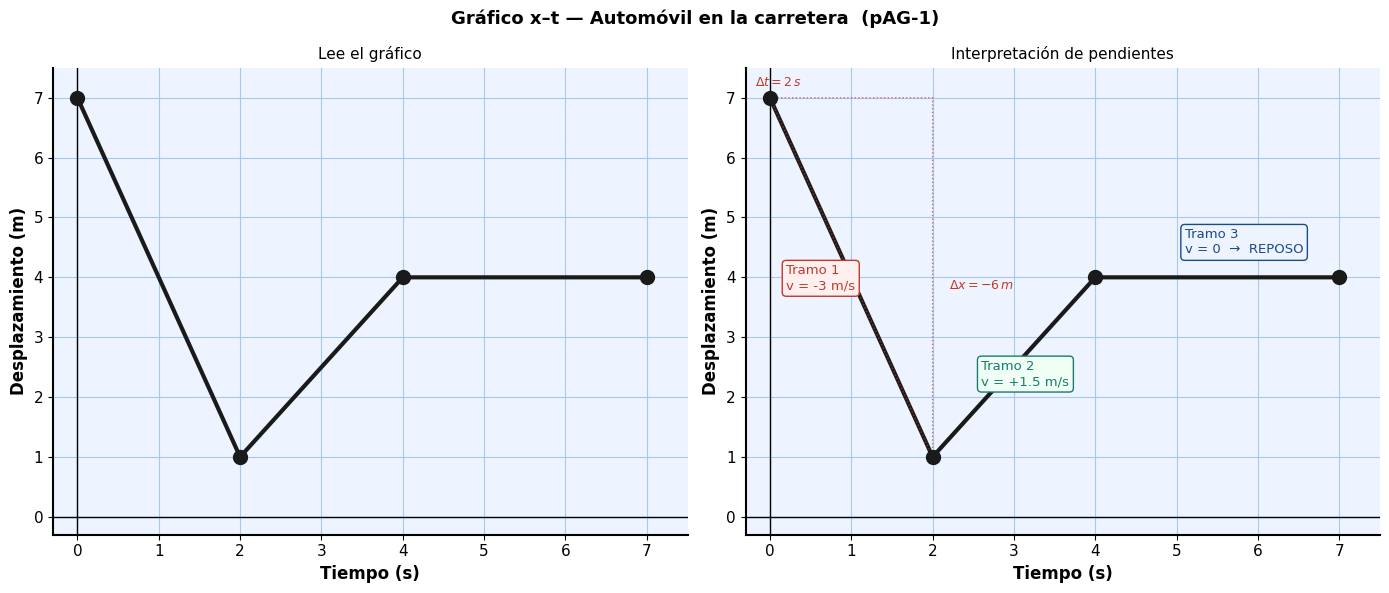

📌 Resumen numérico:
  Tramo 1 (0→2 s):  Δx = -6 m  → v = -3.0 m/s
  Tramo 2 (2→4 s):  Δx = 3 m  → v = +1.5 m/s
  Tramo 3 (4→7 s):  Δx = 0 m   → v = 0 m/s  (REPOSO)
  Desplazamiento total: -3 m
  Distancia total:      9 m


In [7]:
# ── pAG-1: x–t por tramos ────────────────────────────────────────────────────
# TikZ: (0,7)--(2,1)--(4,4)--(7,4)  grilla azul clara
pt = [0, 2, 4, 7]
px = [7, 1, 4, 4]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Gráfico x–t — Automóvil en la carretera  (pAG-1)', fontsize=13, fontweight='bold')

for ax, titulo in [(ax1,'Lee el gráfico'),(ax2,'Interpretación de pendientes')]:
    estilo_tikz(ax)
    ax.plot(pt, px, color=NEGRO, lw=3, solid_capstyle='round')
    for t_,x_ in zip(pt,px): ax.scatter(t_,x_,s=100,color=NEGRO,zorder=5)
    ax.set_xlim(-0.3,7.5); ax.set_ylim(-0.3,7.5)
    ax.set_xticks(range(8)); ax.set_yticks(range(8))
    ax.set_xlabel('Tiempo (s)',fontsize=12,fontweight='bold')
    ax.set_ylabel('Desplazamiento (m)',fontsize=12,fontweight='bold')
    ax.set_title(titulo, fontsize=11)
    ax.axhline(0,color='black',lw=1); ax.axvline(0,color='black',lw=1)

# Anotaciones pedagógicas en ax2
v1=(1-7)/(2-0); v2=(4-1)/(4-2)
ax2.plot([0,2,2,0],[7,7,1,7],color=ROJO,lw=1,linestyle=':',alpha=0.7)
ax2.text(0.2,3.8,f'Tramo 1\nv = {v1:.0f} m/s',fontsize=9.5,color=ROJO,
         bbox=dict(boxstyle='round,pad=0.3',fc='#fff0f0',ec=ROJO))
ax2.text(0.1,7.2,r'$\Delta t=2\,s$',fontsize=9,color=ROJO,ha='center')
ax2.text(2.2,3.8,r'$\Delta x=-6\,m$',fontsize=9,color=ROJO)
ax2.text(2.6,2.2,f'Tramo 2\nv = +{v2} m/s',fontsize=9.5,color=VERDE,
         bbox=dict(boxstyle='round,pad=0.3',fc='#f0fff4',ec=VERDE))
ax2.text(5.1,4.4,'Tramo 3\nv = 0  →  REPOSO',fontsize=9.5,color=AZUL,
         bbox=dict(boxstyle='round,pad=0.3',fc='#eef4ff',ec=AZUL))

plt.tight_layout(); plt.show()

print("📌 Resumen numérico:")
print(f"  Tramo 1 (0→2 s):  Δx = {1-7} m  → v = {v1:.1f} m/s")
print(f"  Tramo 2 (2→4 s):  Δx = {4-1} m  → v = +{v2:.1f} m/s")
print(f"  Tramo 3 (4→7 s):  Δx = 0 m   → v = 0 m/s  (REPOSO)")
print(f"  Desplazamiento total: {4-7} m")
print(f"  Distancia total:      {abs(1-7)+abs(4-1)+0} m")

<div style='background:#fff8e1;border-left:5px solid #e8a838;padding:18px 22px;border-radius:0 12px 12px 0;margin:16px 0'>
<strong>💡 Velocidad media vs. Rapidez media:</strong>

| | Definición | Resultado |
|---|---|---|
| **Velocidad media** | $\bar{v} = \Delta x / \Delta t$ = pendiente de la recta inicio–fin | Puede ser negativa o cero |
| **Rapidez media** | $\bar{r}$ = distancia total / $\Delta t$ | Siempre ≥ 0 |

Son iguales **solo si** el objeto nunca invierte su dirección.
</div>

### 📝 Preguntas — pAG-1

**(a)** Lista los instantes en que el automóvil **no se está moviendo**.

**(b)** ¿Cuál es el **desplazamiento total** durante 0–7 s?

**(c)** Lista los instantes en que el objeto se mueve a su **máxima rapidez**.

**(d)** ¿Cuál fue la **máxima rapidez media** y en qué intervalo?

**(e)** ¿Cuál fue la **máxima velocidad media** y en qué intervalo?

✏️ **Tus respuestas:**

(a) →   (b) →   (c) →   (d) →   (e) →

---
# Sección 2 · Gráfico x–t con curvas Bézier — La criatura Glim
### *(pAG-12)*

Una misteriosa criatura llamada **Glim** ha pasado corriendo frente al laboratorio dejando un extraño rastro. ¡Tu misión es descubrir qué hizo exactamente Glim durante esos 7 segundos!

<div style='background:#f0f4ff;border-radius:14px;padding:28px;font-family:Georgia,serif;line-height:1.8;border:1px solid #c8d4f0'>
<p style='font-family:monospace;font-size:10px;letter-spacing:3px;color:#2c5f8a;margin-bottom:16px'>DIÁLOGO SOCRÁTICO — ESCENA 2</p>

<div style='display:flex;gap:12px;margin-bottom:18px;align-items:flex-start'>
<div style='background:#2c5f8a;color:white;border-radius:50%;width:38px;height:38px;display:flex;align-items:center;justify-content:center;font-weight:bold;flex-shrink:0'>P</div>
<div style='background:white;padding:14px 18px;border-radius:0 14px 14px 14px;border:1px solid #dde4f5;max-width:85%'>Ahora el gráfico tiene curvas, no rectas. ¿Eso cambia cómo lees la velocidad?</div></div>

<div style='display:flex;gap:12px;margin-bottom:18px;align-items:flex-start;flex-direction:row-reverse'>
<div style='background:#1a7a6e;color:white;border-radius:50%;width:38px;height:38px;display:flex;align-items:center;justify-content:center;font-weight:bold;flex-shrink:0'>D</div>
<div style='background:white;padding:14px 18px;border-radius:14px 0 14px 14px;border:1px solid #dde4f5;max-width:85%'>La pendiente ya no es constante. Cada punto tiene una pendiente diferente. La velocidad cambia en todo momento.</div></div>

<div style='display:flex;gap:12px;margin-bottom:18px;align-items:flex-start'>
<div style='background:#2c5f8a;color:white;border-radius:50%;width:38px;height:38px;display:flex;align-items:center;justify-content:center;font-weight:bold;flex-shrink:0'>P</div>
<div style='background:white;padding:14px 18px;border-radius:0 14px 14px 14px;border:1px solid #dde4f5;max-width:85%'>Glim empieza en posición negativa. ¿Qué significa eso?</div></div>

<div style='display:flex;gap:12px;margin-bottom:18px;align-items:flex-start;flex-direction:row-reverse'>
<div style='background:#1a7a6e;color:white;border-radius:50%;width:38px;height:38px;display:flex;align-items:center;justify-content:center;font-weight:bold;flex-shrink:0'>D</div>
<div style='background:white;padding:14px 18px;border-radius:14px 0 14px 14px;border:1px solid #dde4f5;max-width:85%'>Que al inicio estaba al lado negativo del punto de referencia. Cuando el gráfico cruza el eje x, Glim pasa justo por el origen.</div></div>

<div style='display:flex;gap:12px;margin-bottom:18px;align-items:flex-start'>
<div style='background:#2c5f8a;color:white;border-radius:50%;width:38px;height:38px;display:flex;align-items:center;justify-content:center;font-weight:bold;flex-shrink:0'>P</div>
<div style='background:white;padding:14px 18px;border-radius:0 14px 14px 14px;border:1px solid #dde4f5;max-width:85%'>Al final hay un tramo recto horizontal. ¿Qué hace Glim ahí?</div></div>

<div style='display:flex;gap:12px;margin-bottom:0;align-items:flex-start;flex-direction:row-reverse'>
<div style='background:#1a7a6e;color:white;border-radius:50%;width:38px;height:38px;display:flex;align-items:center;justify-content:center;font-weight:bold;flex-shrink:0'>D</div>
<div style='background:white;padding:14px 18px;border-radius:14px 0 14px 14px;border:1px solid #dde4f5;max-width:85%'>Está en reposo. La posición no cambia. Pendiente cero, velocidad cero.</div></div>
</div>

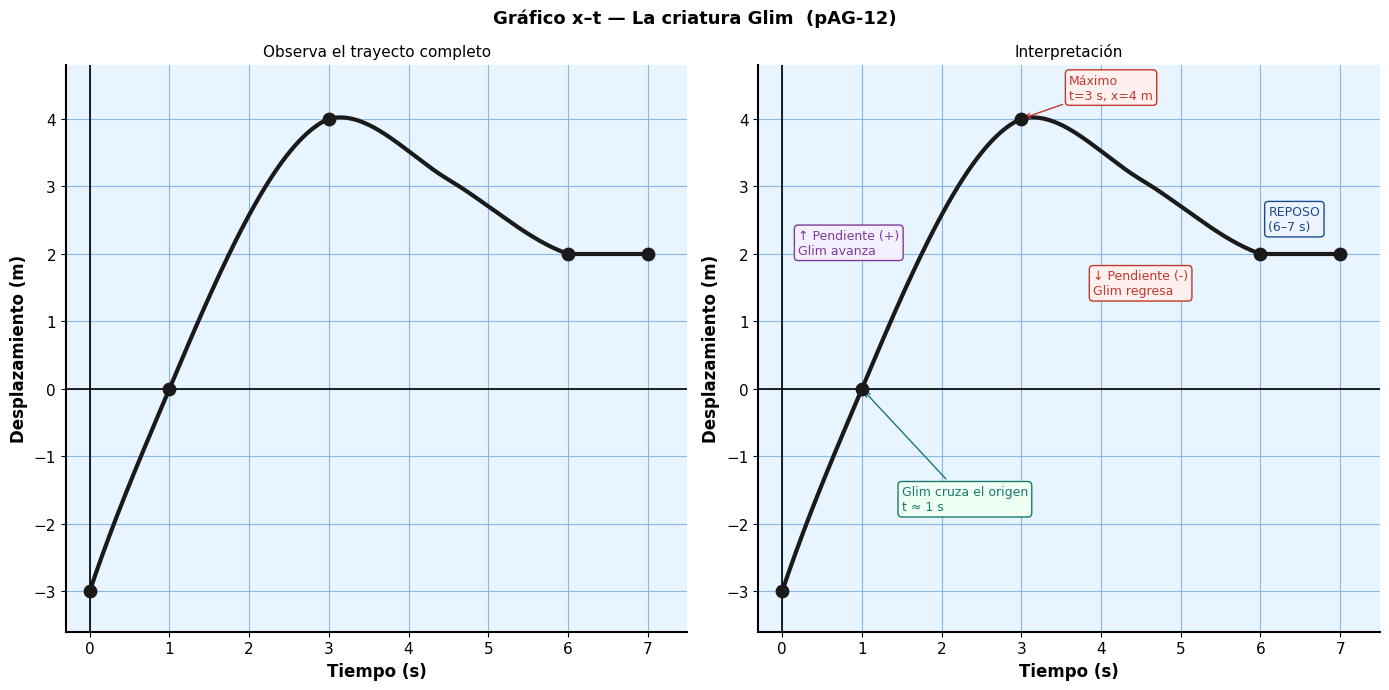

📌 Distancia total recorrida: 9 m
   Desplazamiento total:      5 m
   Velocidad media 0–7 s:     0.714 m/s
   Rapidez media 0–7 s:       1.286 m/s


In [8]:
# ── pAG-12: x–t con curvas Bézier — Glim ─────────────────────────────────────
# TikZ curva 1: (0,-3)..controls(1,0)and(2,3.75)..(3,4)  → subida acelerada
# TikZ curva 2: (3,4)..controls(3.5,4)and(5,2)..(6,2)    → desaceleración
# TikZ recta:   (6,2)--(7,2)                              → reposo
# Puntos destacados: (0,-3),(1,0),(3,4),(6,2),(7,2)

# Curva 1: spline Hermite reproduciendo controles Bézier
t_c1 = np.array([0.0, 1.0, 3.0])
x_c1 = np.array([-3.0, 0.0, 4.0])
dx_c1 = np.array([3.5, 2.8, 0.5])  # derivadas aprox. de los puntos de control
spl1 = CubicHermiteSpline(t_c1, x_c1, dx_c1)
t1d = np.linspace(0, 3, 300); x1d = spl1(t1d)

# Curva 2: (3,4)→(6,2) suavizada
t_c2 = np.array([3.0, 4.5, 6.0])
x_c2 = np.array([4.0, 3.1, 2.0])
dx_c2 = np.array([0.3, -0.7, -0.4])
spl2 = CubicHermiteSpline(t_c2, x_c2, dx_c2)
t2d = np.linspace(3, 6, 200); x2d = spl2(t2d)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle('Gráfico x–t — La criatura Glim  (pAG-12)', fontsize=13, fontweight='bold')

for ax, titulo, anotar in [(ax1,'Observa el trayecto completo',False),(ax2,'Interpretación',True)]:
    estilo_tikz(ax, gc='#88b8e8', bg='#e8f4ff')
    ax.plot(t1d, x1d, color=NEGRO, lw=3)
    ax.plot(t2d, x2d, color=NEGRO, lw=3)
    ax.plot([6,7],[2,2], color=NEGRO, lw=3)
    for t_,x_ in [(0,-3),(1,0),(3,4),(6,2),(7,2)]:
        ax.scatter(t_,x_,s=80,color=NEGRO,zorder=5)
    ax.axhline(0,color='black',lw=1.2); ax.axvline(0,color='black',lw=1.2)
    ax.set_xlim(-0.3,7.5); ax.set_ylim(-3.6,4.8)
    ax.set_xticks(range(8)); ax.set_yticks(range(-3,5))
    ax.set_xlabel('Tiempo (s)',fontsize=12,fontweight='bold')
    ax.set_ylabel('Desplazamiento (m)',fontsize=12,fontweight='bold')
    ax.set_title(titulo, fontsize=11)
    if anotar:
        ax.annotate('Glim cruza el origen\nt ≈ 1 s',xy=(1,0),xytext=(1.5,-1.8),
                   fontsize=9,color=VERDE,arrowprops=dict(arrowstyle='->',color=VERDE),
                   bbox=dict(boxstyle='round,pad=0.3',fc='#f0fff4',ec=VERDE))
        ax.annotate('Máximo\nt=3 s, x=4 m',xy=(3,4),xytext=(3.6,4.3),
                   fontsize=9,color=ROJO,arrowprops=dict(arrowstyle='->',color=ROJO),
                   bbox=dict(boxstyle='round,pad=0.3',fc='#fff0f0',ec=ROJO))
        ax.text(6.1,2.35,'REPOSO\n(6–7 s)',fontsize=9,color=AZUL,
               bbox=dict(boxstyle='round,pad=0.3',fc='#eef4ff',ec=AZUL))
        ax.text(0.2,2.0,'↑ Pendiente (+)\nGlim avanza',fontsize=9,color=MORADO,
               bbox=dict(boxstyle='round,pad=0.3',fc='#f5f0ff',ec=MORADO))
        ax.text(3.9,1.4,'↓ Pendiente (-)\nGlim regresa',fontsize=9,color=ROJO,
               bbox=dict(boxstyle='round,pad=0.3',fc='#fff0f0',ec=ROJO))

plt.tight_layout(); plt.show()

dist_total = abs(0-(-3)) + abs(4-0) + abs(2-4) + 0
desp_total = 2 - (-3)
print(f"📌 Distancia total recorrida: {dist_total} m")
print(f"   Desplazamiento total:      {desp_total} m")
print(f"   Velocidad media 0–7 s:     {desp_total/7:.3f} m/s")
print(f"   Rapidez media 0–7 s:       {dist_total/7:.3f} m/s")

<div style='background:#fff8e1;border-left:5px solid #e8a838;padding:18px 22px;border-radius:0 12px 12px 0;margin:16px 0'>
<strong>💡 Curvas en x–t:</strong>

- Curva **cóncava hacia arriba** (⌣) → velocidad **aumenta** → aceleración positiva
- Curva **cóncava hacia abajo** (⌢) → velocidad **disminuye** → aceleración negativa
- **Punto de inflexión** → aceleración cambia de signo
- La **pendiente de la tangente** en cada punto = velocidad **instantánea**
</div>

### 📝 Preguntas — pAG-12 (Glim)

**(a)** ¿En qué segundo exacto pasó Glim por el punto inicial (x=0)?  
**(b)** ¿Cuándo estuvo Glim más lejos del punto inicial y cuánto fue esa distancia?  
**(c)** ¿En qué intervalo Glim estuvo **regresando** hacia atrás?  
**(d)** ¿En qué momentos se quedó **quieto**?  
**(e)** Calcula la **rapidez media** durante los 7 segundos.  
**(f)** Calcula la **velocidad media** durante los 7 segundos.  
**(g)** Identifica los intervalos donde Glim estuvo **acelerando** y **desacelerando**.  
**(h)** Clasifica los tipos de movimiento por intervalos (MRU / MRUA).  
**(i)** ¿En qué puntos Glim **cambió de dirección**?  
**(j)** Compara rapidez media y velocidad media. ¿Por qué son diferentes?  
**(k)** Describe **detalladamente** el movimiento de Glim durante los 7 segundos.

✏️ **Tus respuestas:**

(a) →   (b) →   (c) →   (d) →   (e) →   (f) →

(g) →   (h) →   (i) →   (j) →

(k) Narrativa →

---
# Sección 3 · Gráfico v–t: área y pendiente — El automóvil que frena
### *(pAG-4)*

La siguiente gráfica representa la **velocidad (m/s)** en función del **tiempo (s)** de un automóvil. Observa que la recta cruza el eje del tiempo.

<div style='background:#fff8f0;border-radius:14px;padding:28px;font-family:Georgia,serif;line-height:1.8;border:1px solid #f0d8b0'>
<p style='font-family:monospace;font-size:10px;letter-spacing:3px;color:#c07010;margin-bottom:16px'>DIÁLOGO SOCRÁTICO — ESCENA 3</p>

<div style='display:flex;gap:12px;margin-bottom:18px;align-items:flex-start'>
<div style='background:#c07010;color:white;border-radius:50%;width:38px;height:38px;display:flex;align-items:center;justify-content:center;font-weight:bold;flex-shrink:0'>P</div>
<div style='background:white;padding:14px 18px;border-radius:0 14px 14px 14px;border:1px solid #f0d8b0;max-width:85%'>La recta cruza el eje horizontal. ¿Qué ocurre en ese instante?</div></div>

<div style='display:flex;gap:12px;margin-bottom:18px;align-items:flex-start;flex-direction:row-reverse'>
<div style='background:#1a7a6e;color:white;border-radius:50%;width:38px;height:38px;display:flex;align-items:center;justify-content:center;font-weight:bold;flex-shrink:0'>D</div>
<div style='background:white;padding:14px 18px;border-radius:14px 0 14px 14px;border:1px solid #f0d8b0;max-width:85%'>La velocidad es cero: el automóvil se detiene. Y luego la velocidad es negativa, cambia de dirección.</div></div>

<div style='display:flex;gap:12px;margin-bottom:18px;align-items:flex-start'>
<div style='background:#c07010;color:white;border-radius:50%;width:38px;height:38px;display:flex;align-items:center;justify-content:center;font-weight:bold;flex-shrink:0'>P</div>
<div style='background:white;padding:14px 18px;border-radius:0 14px 14px 14px;border:1px solid #f0d8b0;max-width:85%'>El área del triángulo entre la recta y el eje en 0–3 s, ¿qué representa?</div></div>

<div style='display:flex;gap:12px;margin-bottom:18px;align-items:flex-start;flex-direction:row-reverse'>
<div style='background:#1a7a6e;color:white;border-radius:50%;width:38px;height:38px;display:flex;align-items:center;justify-content:center;font-weight:bold;flex-shrink:0'>D</div>
<div style='background:white;padding:14px 18px;border-radius:14px 0 14px 14px;border:1px solid #f0d8b0;max-width:85%'>El desplazamiento. Área = ½ × 3 × 3 = 4.5 m. Positivo porque está sobre el eje.</div></div>

<div style='display:flex;gap:12px;margin-bottom:0;align-items:flex-start'>
<div style='background:#c07010;color:white;border-radius:50%;width:38px;height:38px;display:flex;align-items:center;justify-content:center;font-weight:bold;flex-shrink:0'>P</div>
<div style='background:white;padding:14px 18px;border-radius:0 14px 14px 14px;border:1px solid #f0d8b0;max-width:85%'>¿Y la pendiente de esta recta qué representa?</div></div>
</div>

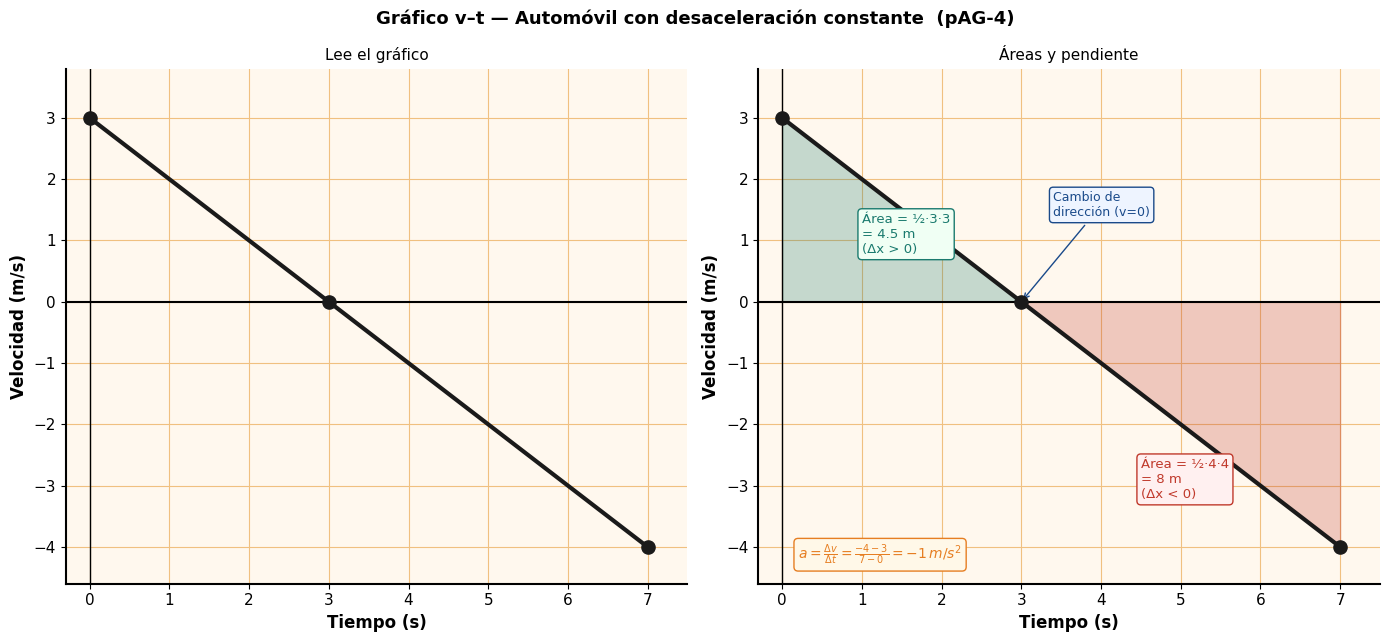

📌 Aceleración: a = -1 m/s² (constante)
   Desplazamiento 0–3 s: +4.5 m
   Desplazamiento 3–7 s: -8.0 m
   Desplazamiento total:  -3.5 m
   Distancia total:       12.5 m


In [9]:
# ── pAG-4: v–t  (0,3)→(7,–4) — grilla naranja ───────────────────────────────
# Pendiente = (-4-3)/(7-0) = -1 m/s²  |  cruce v=0 en t=3 s

t_d = np.linspace(0, 7, 300)
v_d = 3 - t_d   # v(t) = 3 - t

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.5))
fig.suptitle('Gráfico v–t — Automóvil con desaceleración constante  (pAG-4)',
             fontsize=13, fontweight='bold')

for ax, anotar in [(ax1,False),(ax2,True)]:
    estilo_tikz(ax, gc='#f0c080', bg='#fff8ee')
    ax.plot(t_d, v_d, color=NEGRO, lw=3)
    for t_,v_ in [(0,3),(3,0),(7,-4)]: ax.scatter(t_,v_,s=90,color=NEGRO,zorder=5)
    ax.axhline(0,color='black',lw=1.5); ax.axvline(0,color='black',lw=1)
    ax.set_xlim(-0.3,7.5); ax.set_ylim(-4.6,3.8)
    ax.set_xticks(range(8)); ax.set_yticks(range(-4,4))
    ax.set_xlabel('Tiempo (s)',fontsize=12,fontweight='bold')
    ax.set_ylabel('Velocidad (m/s)',fontsize=12,fontweight='bold')
    if anotar:
        ax.set_title('Áreas y pendiente', fontsize=11)
        # Área tramo 0-3 (triángulo positivo)
        tp = t_d[t_d<=3]; vp = v_d[t_d<=3]
        ax.fill_between(tp, vp, 0, alpha=0.25, color=VERDE)
        ax.text(1.0,0.8,'Área = ½·3·3\n= 4.5 m\n(Δx > 0)',fontsize=9.5,color=VERDE,
               bbox=dict(boxstyle='round,pad=0.3',fc='#f0fff4',ec=VERDE))
        # Área tramo 3-7 (triángulo negativo)
        tn = t_d[t_d>=3]; vn = v_d[t_d>=3]
        ax.fill_between(tn, vn, 0, alpha=0.25, color=ROJO)
        ax.text(4.5,-3.2,'Área = ½·4·4\n= 8 m\n(Δx < 0)',fontsize=9.5,color=ROJO,
               bbox=dict(boxstyle='round,pad=0.3',fc='#fff0f0',ec=ROJO))
        # Pendiente
        ax.text(0.2,-4.2,r'$a = \frac{\Delta v}{\Delta t} = \frac{-4-3}{7-0} = -1\,m/s^2$',
               fontsize=10,color=NARANJA,
               bbox=dict(boxstyle='round,pad=0.3',fc='#fff8e8',ec=NARANJA))
        # Cambio de dirección
        ax.annotate('Cambio de\ndirección (v=0)',xy=(3,0),xytext=(3.4,1.4),
                   fontsize=9,color=AZUL,arrowprops=dict(arrowstyle='->',color=AZUL),
                   bbox=dict(boxstyle='round,pad=0.3',fc='#eef4ff',ec=AZUL))
    else:
        ax.set_title('Lee el gráfico', fontsize=11)

plt.tight_layout(); plt.show()
print("📌 Aceleración: a = -1 m/s² (constante)")
print("   Desplazamiento 0–3 s: +4.5 m")
print("   Desplazamiento 3–7 s: -8.0 m")
print("   Desplazamiento total:  -3.5 m")
print("   Distancia total:       12.5 m")

### 📝 Preguntas — pAG-4

**(a)** ¿Cuántas veces el objeto **cambia de dirección**?  
**(b)** ¿Cuál es la **aceleración** representada en este gráfico?  
**(c)** ¿Cuál es el **desplazamiento** durante el intervalo 0–3 s?  
**(d)** ¿Cuál es la **distancia recorrida** durante el intervalo 0–7 s?

✏️ **Tus respuestas:**

(a) →   (b) →   (c) →   (d) →

---
# Sección 4 · Gráfico x–t con spline suave — Análisis de movimiento
### *(pAG-5)*

La siguiente gráfica representa la **posición (m)** en función del **tiempo (s)** de un automóvil. La curva pasa por los puntos: (0,0), (1,4), (3,7), (5,4), (7,2).

<div style='background:#f0f4ff;border-radius:14px;padding:28px;font-family:Georgia,serif;line-height:1.8;border:1px solid #c8d4f0'>
<p style='font-family:monospace;font-size:10px;letter-spacing:3px;color:#2c5f8a;margin-bottom:16px'>DIÁLOGO SOCRÁTICO — ESCENA 4</p>

<div style='display:flex;gap:12px;margin-bottom:18px;align-items:flex-start'>
<div style='background:#2c5f8a;color:white;border-radius:50%;width:38px;height:38px;display:flex;align-items:center;justify-content:center;font-weight:bold;flex-shrink:0'>P</div>
<div style='background:white;padding:14px 18px;border-radius:0 14px 14px 14px;border:1px solid #dde4f5;max-width:85%'>En t = 3 s hay un punto especial. ¿Qué ocurre ahí?</div></div>

<div style='display:flex;gap:12px;margin-bottom:18px;align-items:flex-start;flex-direction:row-reverse'>
<div style='background:#1a7a6e;color:white;border-radius:50%;width:38px;height:38px;display:flex;align-items:center;justify-content:center;font-weight:bold;flex-shrink:0'>D</div>
<div style='background:white;padding:14px 18px;border-radius:14px 0 14px 14px;border:1px solid #dde4f5;max-width:85%'>Es el punto más alto. La curva cambia de subir a bajar. La pendiente era positiva y ahora se vuelve negativa. En ese instante exacto, la pendiente es cero.</div></div>

<div style='display:flex;gap:12px;margin-bottom:18px;align-items:flex-start'>
<div style='background:#2c5f8a;color:white;border-radius:50%;width:38px;height:38px;display:flex;align-items:center;justify-content:center;font-weight:bold;flex-shrink:0'>P</div>
<div style='background:white;padding:14px 18px;border-radius:0 14px 14px 14px;border:1px solid #dde4f5;max-width:85%'>¿Y si la pendiente es cero, qué significa para la velocidad en t = 3 s?</div></div>

<div style='display:flex;gap:12px;margin-bottom:18px;align-items:flex-start;flex-direction:row-reverse'>
<div style='background:#1a7a6e;color:white;border-radius:50%;width:38px;height:38px;display:flex;align-items:center;justify-content:center;font-weight:bold;flex-shrink:0'>D</div>
<div style='background:white;padding:14px 18px;border-radius:14px 0 14px 14px;border:1px solid #dde4f5;max-width:85%'>¡La velocidad es cero en t = 3 s! El automóvil se detiene instantáneamente antes de cambiar de dirección. Lo leo directamente del gráfico.</div></div>

<div style='display:flex;gap:12px;margin-bottom:0;align-items:flex-start'>
<div style='background:#2c5f8a;color:white;border-radius:50%;width:38px;height:38px;display:flex;align-items:center;justify-content:center;font-weight:bold;flex-shrink:0'>P</div>
<div style='background:white;padding:14px 18px;border-radius:0 14px 14px 14px;border:1px solid #dde4f5;max-width:85%'>Ahora la trampa: de t=1 a t=5, el desplazamiento fue cero y la velocidad media fue cero, ¡pero el objeto sí se movió! ¿Hay contradicción?</div></div>
</div>

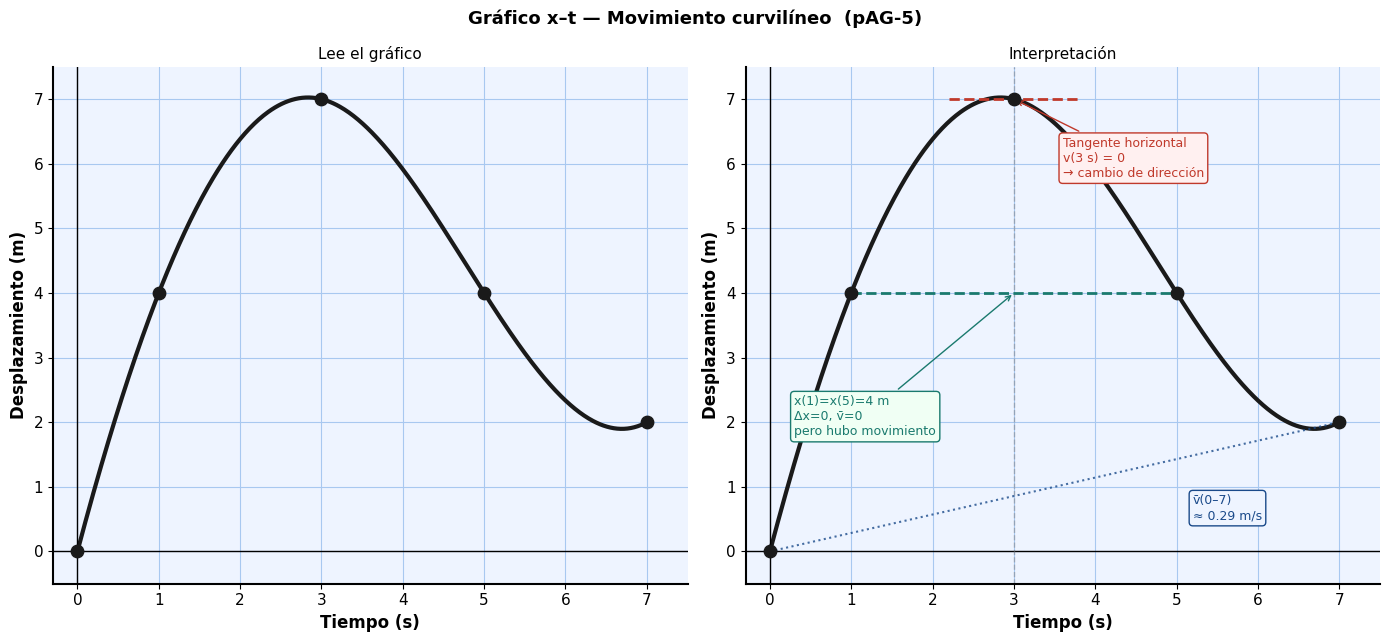

In [10]:
# ── pAG-5: x–t spline smooth — (0,0),(1,4),(3,7),(5,4),(7,2) ─────────────────
# TikZ: plot[smooth, tension=0.6]

pt5 = np.array([0,1,3,5,7], dtype=float)
px5 = np.array([0,4,7,4,2], dtype=float)
t5d = np.linspace(0, 7, 500)
spl5 = make_interp_spline(pt5, px5, k=3)
x5d  = spl5(t5d)
v5d  = spl5.derivative()(t5d)   # velocidad instantánea

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.5))
fig.suptitle('Gráfico x–t — Movimiento curvilíneo  (pAG-5)', fontsize=13, fontweight='bold')

for ax, anotar in [(ax1,False),(ax2,True)]:
    estilo_tikz(ax)
    ax.plot(t5d, x5d, color=NEGRO, lw=3)
    for t_,x_ in zip(pt5,px5): ax.scatter(t_,x_,s=80,color=NEGRO,zorder=5)
    ax.axhline(0,color='black',lw=1); ax.axvline(0,color='black',lw=1)
    ax.set_xlim(-0.3,7.5); ax.set_ylim(-0.5,7.5)
    ax.set_xticks(range(8)); ax.set_yticks(range(8))
    ax.set_xlabel('Tiempo (s)',fontsize=12,fontweight='bold')
    ax.set_ylabel('Desplazamiento (m)',fontsize=12,fontweight='bold')
    if anotar:
        ax.set_title('Interpretación', fontsize=11)
        ax.axvline(3,color='gray',lw=1,linestyle='--',alpha=0.5)
        ax.plot([2.2,3.8],[7,7],color=ROJO,lw=2,linestyle='--')
        ax.annotate('Tangente horizontal\nv(3 s) = 0\n→ cambio de dirección',
                   xy=(3,7),xytext=(3.6,5.8),fontsize=9,color=ROJO,
                   arrowprops=dict(arrowstyle='->',color=ROJO),
                   bbox=dict(boxstyle='round,pad=0.3',fc='#fff0f0',ec=ROJO))
        ax.plot([1,5],[4,4],color=VERDE,lw=2,linestyle='--')
        ax.annotate('x(1)=x(5)=4 m\nΔx=0, v̄=0\npero hubo movimiento',
                   xy=(3,4),xytext=(0.3,1.8),fontsize=9,color=VERDE,
                   arrowprops=dict(arrowstyle='->',color=VERDE),
                   bbox=dict(boxstyle='round,pad=0.3',fc='#f0fff4',ec=VERDE))
        vmed = (2-0)/7
        ax.plot([0,7],[0,2],color=AZUL,lw=1.5,linestyle=':',alpha=0.8)
        ax.text(5.2,0.5,f'v̄(0–7)\n≈ {vmed:.2f} m/s',fontsize=9,color=AZUL,
               bbox=dict(boxstyle='round,pad=0.3',fc='#eef4ff',ec=AZUL))
    else:
        ax.set_title('Lee el gráfico', fontsize=11)

plt.tight_layout(); plt.show()

In [11]:
# ── v–t derivado de pAG-5: exploración interactiva ───────────────────────────
if PLOTLY_OK:
    fig2 = make_subplots(rows=2,cols=1,shared_xaxes=True,
                         subplot_titles=['Posición x(t)  (pAG-5)',
                                         'Velocidad v(t) — derivada del spline'],
                         vertical_spacing=0.1)
    fig2.add_trace(go.Scatter(x=t5d,y=x5d,mode='lines',
                              line=dict(color='#1a1a1a',width=3),name='x(t)',
                              hovertemplate='t=%{x:.2f}s<br>x=%{y:.2f}m'),row=1,col=1)
    fig2.add_trace(go.Scatter(x=t5d,y=v5d,mode='lines',
                              line=dict(color='#c0392b',width=3),name='v(t)',
                              fill='tozeroy',fillcolor='rgba(192,57,43,0.1)',
                              hovertemplate='t=%{x:.2f}s<br>v=%{y:.2f}m/s'),row=2,col=1)
    fig2.add_hline(y=0,line_dash='dash',line_color='gray',row=2,col=1)
    fig2.add_vline(x=3,line_dash='dot',line_color='#c0392b',opacity=0.5)
    fig2.update_layout(height=550,
        title_text='pAG-5 — Pasa el cursor para explorar x(t) y v(t) en cada instante',
        hovermode='x unified',plot_bgcolor='#f5f5f5',paper_bgcolor='#fafafa')
    fig2.update_yaxes(title_text='x (m)',row=1,col=1)
    fig2.update_yaxes(title_text='v (m/s)',row=2,col=1)
    fig2.update_xaxes(title_text='t (s)',row=2,col=1)
    fig2.show()
    print("💡 En el gráfico v–t: busca el instante donde v = 0. ¿Coincide con el máximo de x–t?")
else:
    fig,ax = plt.subplots(figsize=(10,4))
    estilo_tikz(ax,gc='#f0a0a0',bg='#fff5f5')
    ax.plot(t5d,v5d,color=ROJO,lw=2.5)
    ax.fill_between(t5d,v5d,0,where=(v5d>=0),alpha=0.15,color=VERDE)
    ax.fill_between(t5d,v5d,0,where=(v5d<0),alpha=0.15,color=ROJO)
    ax.axhline(0,color='black',lw=1)
    ax.axvline(3,color='gray',lw=1,linestyle='--',alpha=0.5)
    ax.set_xlabel('Tiempo (s)'); ax.set_ylabel('Velocidad (m/s)')
    ax.set_title('v–t derivado del gráfico pAG-5')
    plt.tight_layout(); plt.show()

💡 En el gráfico v–t: busca el instante donde v = 0. ¿Coincide con el máximo de x–t?


### 📝 Preguntas — pAG-5

**(a)** ¿Cuál es el **desplazamiento total** durante 0–7 s?  
**(b)** ¿Cuál es la **distancia total recorrida** durante 0–7 s?  
**(c)** ¿En qué instante el objeto **cambia de dirección**?  
**(d)** ¿Cuál es la velocidad en **t = 3 s**? Justifica usando el gráfico.  
**(e)** *"De t=1 a t=5 el objeto no se desplazó y su velocidad media fue cero, pero sí se movió."* Explica por qué **no hay contradicción**.

✏️ **Tus respuestas:**

(a) →   (b) →   (c) →   (d) →

(e) →

---
# 📋 Tabla resumen

| Lo que quieres | En x–t | En v–t | En a–t |
|---|---|---|---|
| **Posición** | Lectura directa | — | — |
| **Desplazamiento** | Diferencia entre puntos | **Área bajo la curva** | — |
| **Velocidad** | **Pendiente** | Lectura directa | — |
| **Aceleración** | Curvatura | **Pendiente** | Lectura directa |
| **Reposo** | Recta horizontal | v = 0 | — |
| **MRU** | Recta oblicua | Recta horizontal | a = 0 |
| **MRUA** | Parábola | Recta oblicua | Constante ≠ 0 |
| **Cambio de dirección** | Máximo o mínimo local | Cruce por v = 0 | — |

### 7 reglas de oro:
1. 🔺 Pendiente en **x–t** → velocidad
2. 🔺 Pendiente en **v–t** → aceleración
3. 📐 Área bajo **v–t** → desplazamiento
4. ➡️ Recta horizontal → variable **constante**
5. 📈 Mayor inclinación → mayor **rapidez**
6. 🔄 Cruce por cero en **v–t** → **cambio de dirección**
7. ⚠️ Desplazamiento neto = 0 **≠** distancia recorrida = 0

<div style='background:linear-gradient(135deg,#1a1a2e,#0f3460);padding:36px 40px;border-radius:18px;color:white;font-family:Georgia,serif;margin-top:30px'>
<p style='font-family:monospace;font-size:10px;letter-spacing:4px;color:#e8a838;margin-bottom:12px'>CIERRE DE LA LECTURA</p>
<h3 style='color:#e8a838;margin-bottom:14px'>"Un gráfico vale más que mil ecuaciones — pero solo si sabes leerlo."</h3>
<p style='color:#c8c8d8;line-height:1.8;margin-bottom:12px'>Los gráficos no son decoración de la física: <strong style='color:white'>son la física</strong>. La pendiente es una tasa de cambio, el área es una acumulación, y la forma de la curva cuenta la historia completa del movimiento.</p>
<p style='color:#c8c8d8;line-height:1.8'>Cuando domines la lectura gráfica, podrás analizar cualquier movimiento con las mismas tres herramientas: <strong style='color:#e8a838'>pendiente · área · forma de la curva</strong>.</p>
<hr style='border:none;border-top:1px solid rgba(255,255,255,0.15);margin:20px 0'>
<p style='font-family:monospace;font-size:11px;color:#8888aa'>Lic. Hayzar Hernández Bustos · Física 10° · Corporación Universitaria Reformada · Barranquilla, Colombia</p>
</div>